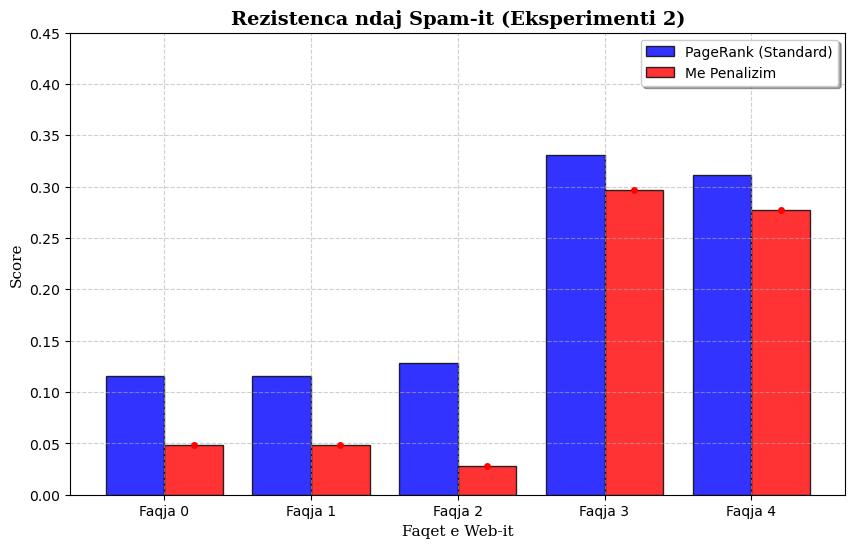

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
if not os.path.exists('figures'): os.makedirs('figures')
#Eksperimenti 2:Drejtues i renditjes rezistente ndaj spam-it;pergjegjes per eksperimentin link farm.
#Punoi;Redian Dida
#Grupi nr.5
adj = np.array([[0,1,1,0,0],[1,0,1,0,0],[1,1,0,1,0],[0,0,0,0,1],[0,0,0,1,0]])

def calculate_pagerank(M, d=0.85):
    n = len(M)
    v = np.ones(n) / n
    M_norm = M / np.where(M.sum(axis=1)[:, None] == 0, 1, M.sum(axis=1)[:, None])
    for _ in range(50): v = (1 - d) / n + d * (M_norm.T @ v)
    return v

P = calculate_pagerank(adj)
Sp = adj.sum(axis=1) / np.max(adj.sum(axis=1))
S = P - 0.1 * Sp

# --- Grafiku i Stilizuar ---
plt.figure(figsize=(10, 6), dpi=100)
faqet = [f"Faqja {i}" for i in range(len(P))]
x = np.arange(len(faqet))

plt.bar(x - 0.2, P, 0.4, label='PageRank (Standard)', color='blue', edgecolor='black', alpha=0.8)
plt.bar(x + 0.2, S, 0.4, label='Me Penalizim', color='red', edgecolor='black', alpha=0.8)
plt.plot(x + 0.2, S, 'ro', markersize=4)

plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Rezistenca ndaj Spam-it (Eksperimenti 2)', fontsize=14, fontweight='bold', family='serif')
plt.xlabel('Faqet e Web-it', fontsize=11, family='serif')
plt.ylabel('Score', fontsize=11, family='serif')
plt.xticks(x, faqet) 
plt.ylim(0, 0.45)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.savefig('figures/eksperimenti_2.png')
plt.show()